## Ensemble forecast and verification exhibiting anomalous RPC ##

The following script defines a verification $Y$ drawn from a forecast distribution which is normal with mean $m(\pi)$ and a fixed standard deviation $\sin(\phi)$ where $\phi$ is prescribed. The mean $m(\pi)$ is again normal with mean zero and standard deviation $\cos(\phi)$. As a result, $Y$ has overall variance equal to one.

The forecast mean is defined as $m(f) = $ `Signal *` $ m(\pi)$ where `Signal` is prescribed.

### Prescribed quantities ###

$\cos(\phi) = r(m(\pi), Y)$ is the correlation between $m(\pi)$ and the verification $Y$ (equal to the correlation between $m(f)$ and the verification $Y$).

`Signal` defines $m(f)$ as $m(f) = $ `Signal *` $ m(\pi)$

`nr_timestamps` is the number of time stamps

`nr_ensemblemembers` is the number of ensemble members

### Derived analytic quantities ###

`Err` is the error between $m(f)$ and $Y$, that is $E((m(f) - Y)^2)$

$\cos(\psi) = r(m(f), Z)$ is the correlation between the mean $m(f)$ of $f$ and a draw $Z$ from $f$

$RPC = \cos(\phi)/ \cos(\psi)$

In [1]:
import numpy as np

In [3]:
nr_timestamps = 100
nr_ensemblemembers = 25
phi = 2 * np.pi * 0.15
Signal = 1
timestamps = np.arange(1, nr_timestamps)
M_pi = np.cos(phi) * np.random.normal(size=(nr_timestamps,1))
Y = M_pi + np.sin(phi) * np.random.normal(size=(nr_timestamps,1))
M_f = Signal * M_pi
Err = np.sqrt(1 + Signal**2 * np.cos(phi)**2 - 2 * Signal * np.cos(phi)**2)
var_M_f = (Signal**2)*(np.cos(phi)**2)
psi = np.arccos(np.sqrt(var_M_f / (Err**2 + var_M_f)))
ensemble = np.tile(M_f, (1, nr_ensemblemembers)) + Err * np.random.normal(size=(nr_timestamps,nr_ensemblemembers))
#Y = Y - Y.mean()
#ensemble = ensemble - ensemble.mean()

Y = np.load("Y_normal.npy")
ensemble = np.load("ensemble_normal.npy")

Quantities derived analytically:

In [4]:
print('Ensemble mean error (= ensemble std)', Err)
print('correlation between m(f) and Y', np.cos(phi))
print('correlation between m(f) and Z', np.cos(psi))
print('RPC: ', np.cos(phi)/ np.cos(psi))

Ensemble mean error (= ensemble std) 0.8090169943749475
correlation between m(f) and Y 0.5877852522924731
correlation between m(f) and Z 0.5877852522924731
RPC:  1.0


In [5]:
m_f = np.mean(ensemble, 1).reshape(nr_timestamps, 1)
v_f = np.mean(np.var(ensemble, 1))
r_pi = np.mean(m_f * Y) / (np.std(m_f) * np.std(Y))
r_f = np.sqrt(np.var(m_f) / (v_f + np.var(m_f)))
err = np.sqrt(np.mean((Y - m_f)**2))

Quantities derived empirically:

In [6]:
print('Ensemble std', np.sqrt(v_f))
print('Ensemble mean error', err)
print('correlation between m(f) and Y', r_pi)
print('correlation between m(f) and Z', r_f)
print('RPC: ', r_pi / r_f)

Ensemble std 0.8021722662723202
Ensemble mean error 0.7774694526779375
correlation between m(f) and Y 0.6516102407062003
correlation between m(f) and Z 0.6260273679800933
RPC:  1.040865422239688


In [7]:
%run compute_snr.py

In [276]:
#np.save("Y_normal.npy", Y)
#np.save("ensemble_normal.npy", ensemble)

In [8]:
crps_samples = bootstrap(score_SSCrat, ensemble, Y.flatten(), 100, scoring_rule=scoringrules.crps_ensemble)

ERROR:2025-09-29 02:22:16,162:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/eviatar/miniconda3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/eviatar/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/eviatar/miniconda3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_UNKNOWN
100%|█████████████████████████████████████████| 100/100 [32:17<00:00, 19.37s/it]


In [49]:
score_SSCrat(ensemble, Y.flatten(), scoring_rule=scoringrules.crps_ensemble)

(np.float32(0.73003626), np.float32(0.73397255))

In [50]:
0.73003626/0.73397255

0.994637006520203

In [12]:
import matplotlib.pyplot as plt

In [48]:
np.save("crps_samples_normal.npy", crps_samples)

In [10]:
crps_samples_anom = np.load("crps_samples_anomalous.npy")

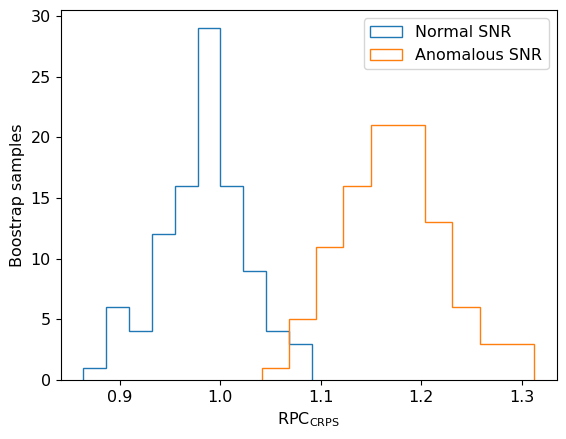

In [16]:
plt.rcParams.update({'font.size': 11.5})
plt.hist(crps_samples[:, 0]/crps_samples[:, 1], histtype='step', label="Normal SNR")
plt.hist(crps_samples_anom[:, 0]/crps_samples_anom[:, 1], histtype='step', label="Anomalous SNR")
plt.xlabel(r"$\text{RPC}_\text{CRPS}$")
plt.ylabel("Boostrap samples")
plt.legend()
plt.savefig("hist_comp.pdf")

In [368]:
np.quantile(crps_samples[:, 0]/crps_samples[:, 1], 0.95)

np.float32(1.1348655)

In [300]:
np.var(np.log10(crps_samples[:, 0]/crps_samples[:, 1]))

np.float32(0.000613407)

In [443]:
probs = [1 - scipy.stats.norm(loc=M_f[i], scale=Err).cdf(0) for i in range(nr_timestamps)]

In [459]:
np.array(probs).mean()

np.float64(0.5186533001163538)

In [17]:
bin_samples_log = bootstrap_bin(score_SSCrat_bin, np.clip((ensemble > 0).mean(axis=1), 1e-2, 1 - 1e-2), (Y.flatten() > 0).astype(int), 100,
                             scoring_rule=scoringrules.log_score)

  0%|                                                   | 0/100 [00:00<?, ?it/s]

[Array(-0.00045538, dtype=float32), Array(-0.00051308, dtype=float32)] 0.7067753696134813 0.41501011328401377


  2%|▊                                          | 2/100 [00:19<15:15,  9.34s/it]

[Array(0.00011158, dtype=float32), Array(0.01501119, dtype=float32)] 0.2483435518877497 0.4721246922467346


  3%|█▎                                         | 3/100 [00:42<25:06, 15.53s/it]

...

[Array(1.4305115e-06, dtype=float32), Array(-2.1457672e-06, dtype=float32)] -0.21206096920867942 0.6113835748311615


 99%|█████████████████████████████████████████▌| 99/100 [16:59<00:08,  8.26s/it]

[Array(2.2649765e-05, dtype=float32), Array(-0.00093627, dtype=float32)] 0.14165962455226164 0.5763620086837903


100%|█████████████████████████████████████████| 100/100 [17:09<00:00, 10.29s/it]

[Array(2.1576881e-05, dtype=float32), Array(7.367134e-05, dtype=float32)] -0.16852481857087875 0.7328356975352259


In [51]:
score_SSCrat_bin(np.clip((ensemble > 0).mean(axis=1), 1e-2, 1 - 1e-2), (Y.flatten() > 0).astype(int),
                             scoring_rule=scoringrules.log_score)

[Array(-2.3841858e-06, dtype=float32), Array(2.861023e-06, dtype=float32)] 0.011935535760075023 0.6518636103013099


(Array(0.789485, dtype=float32), Array(0.88226426, dtype=float32))

In [52]:
0.789485/0.88226426

0.8948396028192278

In [437]:
bin_samples_log[:, 0]/bin_samples_log[:, 1]

array([0.9891793 , 1.1889123 , 0.98066956, 0.94159764, 1.073525  ,
       0.95433664, 1.1378118 , 1.0797932 , 1.4150102 , 1.1612079 ,
       0.9816453 , 1.2521335 , 1.3319777 , 1.1150947 , 1.0201209 ,
       1.0944041 , 1.212924  , 1.1002986 , 1.2714527 , 1.1316825 ,
       0.9738823 , 0.9590314 , 1.3664877 , 1.3921844 , 1.1347853 ,
       1.0099618 , 1.097327  , 1.0322365 , 1.1601821 , 1.2148987 ,
       0.9456455 , 1.0325223 , 0.892234  , 0.9257797 , 1.7069753 ,
       1.3353955 , 1.0179659 , 0.9828634 , 1.0295807 , 0.9774836 ,
       0.99012333, 1.0923284 , 1.0493653 , 1.5554694 , 1.2729139 ,
       1.042706  , 0.9470817 , 1.0339085 , 0.9320651 , 1.6376793 ,
       1.1093894 , 1.0174305 , 0.97241706, 1.0980117 , 1.2484953 ,
       1.1210003 , 0.89975286, 1.3522196 , 1.00432   , 1.0820693 ,
       1.0363445 , 0.92941064, 1.2008991 , 1.0298748 , 0.92414135,
       1.2541578 , 0.        , 0.95156646, 1.082601  , 0.9338494 ,
       1.3003482 , 1.0063611 , 0.8399818 , 1.2391907 , 0.98120

In [422]:
bin_samples_log2 = bootstrap_bin(score_SSCrat_bin, np.clip(((ensemble - Y.mean()) > 0).mean(axis=1), 1e-2, 1 - 1e-2), ((Y - Y.mean()).flatten() > 0).astype(int), 1,
                             scoring_rule=scoringrules.log_score)

100%|█████████████████████████████████████████████| 1/1 [00:06<00:00,  6.98s/it]

[Array(-0.00115752, dtype=float32), Array(0.00044762, dtype=float32)] 0.3411732733533943 1.1540076676889952


In [354]:
rats2 = bin_samples_log2[:, 0]/bin_samples_log2[:, 1]
rats2 = rats2[rats2 > 0]

In [18]:
samps = bin_samples_log#np.concatenate([bin_samples_log, bin_samples_log2])
rats = samps[:, 0]/samps[:, 1]
rats = rats[rats > 0]

In [454]:
np.quantile(rats, 0.15)

np.float32(1.1300126)

In [25]:
np.quantile(rats, 0.05)

np.float32(0.8390071)

In [29]:
np.save("logs_samples_normal.npy", rats)

In [28]:
len(rats)

100

In [27]:
np.mean(np.log10(rats))

np.float32(-0.04216863)

In [146]:
np.nanquantile(crps_samples[:100, 0]/crps_samples[:100, 1], (0.15, 0.85))

array([0.94575004, 1.1036754 ])

In [392]:
sum(np.concatenate([bin_samples_log, bin_samples_log2]) > 1)

array([0, 9])

In [393]:
bin_samples_log

array([[0.80944896, 0.51893187],
       [0.84987336, 0.6189655 ],
       [0.92210656,        nan],
       [0.8243605 , 0.71999043],
       [0.800233  , 0.5905963 ],
       [0.8025462 , 0.5922092 ],
       [0.8102282 , 0.50958   ],
       [0.7883079 , 0.3261571 ],
       [0.78140074,        inf],
       [0.7390158 , 0.4159802 ],
       [0.83502537, 0.6380539 ],
       [0.7986869 , 0.5504449 ],
       [0.82449204,        nan],
       [0.78745675, 0.66241634],
       [0.7794658 , 0.5227737 ],
       [0.82534206,        inf],
       [0.8312388 , 0.5748697 ],
       [0.85858697, 0.6147369 ],
       [0.8083157 , 0.61631304],
       [0.7353719 , 0.38583857],
       [0.82951367, 0.42134127],
       [0.8186697 , 0.43304956],
       [0.7679435 , 0.52632207],
       [0.90115446, 0.7172069 ],
       [0.8614224 , 0.4594262 ],
       [0.7714765 , 0.5476618 ],
       [0.8209941 , 0.61576486],
       [0.77292746,        inf],
       [0.81282043, 0.67969656],
       [0.82151115, 0.72613704],
       [0.

In [147]:
sum(crps_samples[:100, 0]/crps_samples[:100, 1] > 1)

np.int64(63)

In [76]:
score_SSCrat_bin(np.clip((ensemble > 0).mean(axis=1), 1e-6, 1 - 1e-6), (Y.flatten() > 0).astype(int),
                             scoring_rule=scoringrules.log_score)

[Array(0.01124436, dtype=float32), Array(0.01706445, dtype=float32)] -0.13710759666093592 0.8577060634300478


Array(0.953857, dtype=float32)

In [122]:
scoringrules.log_score?

Signature:
scoringrules.log_score(
    obs: 'ArrayLike',
    fct: 'ArrayLike',
    /,
    *,
    backend: 'Backend' = None,
) -> 'Array'
Docstring:
Compute the Logarithmic Score (LS) for probability forecasts for binary outcomes.

The LS is formulated as

.. math::
   LS(f, y) = -\log|f + y - 1|,

where :math:`f \in [0, 1]` is the predicted probability of an event and :math:`y \in \{0, 1\}` the actual outcome.

Parameters
----------
obs : array_like
    Observed outcome, either 0 or 1.
fct : array_like
    Forecasted probabilities between 0 and 1.
backend : str
    The name of the backend used for computations. Defaults to 'numpy'.

Returns
-------
score:
    The computed Log Score.
File:      ~/miniconda3/lib/python3.12/site-packages/scoringrules/_brier.py
Type:      function

In [570]:
bin_samples = bootstrap_bin(score_SSCrat_bin, (ensemble > 0).mean(axis=1), (Y.flatten() > 0).astype(int), 100,
                            scoring_rule=scoringrules.log_score)

[Array(0.00038007, dtype=float32), Array(0.00073359, dtype=float32)] -0.5105830590422912 1.0581908885449662
[Array(-0.00203059, dtype=float32), Array(0.00077871, dtype=float32)] -0.6945493513837527 2.001689399211589
[Array(-0.00030655, dtype=float32), Array(-0.0010474, dtype=float32)] -0.6543542081366599 2.07586509455154
[Array(-0.00041652, dtype=float32), Array(0.00176198, dtype=float32)] -0.8897600633254027 0.5584197872502046
[Array(-8.08388e-06, dtype=float32), Array(-0.00019084, dtype=float32)] -0.05319998129932213 2.5790865689947733
[Array(-1.6868114e-05, dtype=float32), Array(1.1869922e-06, dtype=float32)] -0.6012512088114651 2.3981862475399924
[Array(0.00027719, dtype=float32), Array(0.00018015, dtype=float32)] -7.710665280139031 11.92879204737169
[Array(-5.848706e-07, dtype=float32), Array(1.296266e-07, dtype=float32)] 0.47770043538328144 2.3790996513039655
[Array(-0.00198299, dtype=float32), Array(-0.00092559, dtype=float32)] -1.0775680721835381 3.91621406403229
[Array(4.83542

In [572]:
bin_samples.mean()

np.float32(1.2472653)

In [323]:
mse_samples = bootstrap(score_SSCrat, ensemble, Y.flatten(), 100, scoring_rule=lambda y, X: (X.mean(axis=1 if len(X.shape) > 1 else 0) - y)**2)

7.892364102652817 5.746545829019573 0.09464821629266262 1.6212636152034103
1.3430068804217694
10.231404029675437 8.167901840540633 0.07160188781654997 1.5591879022159123
1.2361504467404003
14.427103396932493 11.389333017637352 0.29000561385491563 1.643311180179374
1.2342889497332692
14.1034103997114 10.675136340045698 0.1258283237389339 1.9460066230984336
1.3412370247455265
14.689130661684313 10.16928741613913 0.24105425777277398 2.0859667498481356
1.4553637464621594
10.75515262194759 7.863205697871939 0.07257867920652877 1.6348773897188584
1.4352007852804605
12.619574696690135 5.805336037479566 0.1505357905941128 2.3203764352182477
1.4995436841105652
12.371652882262795 9.61681038205204 0.22222222017451532 1.6393347012924053
1.2451815276864289
13.54877565969131 8.439504261494 0.1691919025147314 2.0293680277133244
1.552414441128121
18.45296094163694 11.851334829561425 0.30746706436304533 2.2975166984681232
1.4052920768739343
12.135598652822956 11.005017022622306 0.12717534728995916 1.37

In [264]:
score_SSCrat(ensemble, Y.flatten(), scoring_rule=lambda y, X: (X.mean(axis=1 if len(X.shape) > 1 else 0) - y)**2)

25.073069334228073 22.026774524698837 7.976545454581099e-11 1.895705631787399
1.4402194766227643


(np.float64(0.8302735461413145), np.float64(0.5764909860046196))

In [265]:
mse_samples.mean(axis=0)

array([0.83408507, 0.61120658])

In [55]:
np.quantile(crps_samples[:, 0]/crps_samples[:, 1], [0.025, 0.5, 0.975])

array([0.89174776, 0.9865616 , 1.07317623])

In [56]:
np.quantile(rats, [0.025, 0.5, 0.975])

array([0.82844936, 0.89899236, 1.03679975])

In [34]:
rpc_samples = bootstrap(classic_RPC, ensemble, Y.flatten(), 100)

100%|███████████████████████████████████████| 100/100 [00:00<00:00, 2552.97it/s]


In [40]:
scipy.stats.kurtosis(np.log10(rpc_samples))

np.float64(-0.3956009360247874)

In [46]:
np.quantile(rats, 0.5)

np.float32(0.89899236)

In [44]:
sum(rats > 1)

np.int64(8)

In [432]:
np.save("logs_samples_normal.npy", rats)

(array([  1.,   0.,   0.,   0.,   1.,   7.,  14., 143., 309.,  25.]),
 array([-2.11046895, -1.8514579 , -1.59244685, -1.3334358 , -1.07442475,
        -0.8154137 , -0.55640264, -0.29739159, -0.03838054,  0.22063051,
         0.47964156]),
 <BarContainer object of 10 artists>)

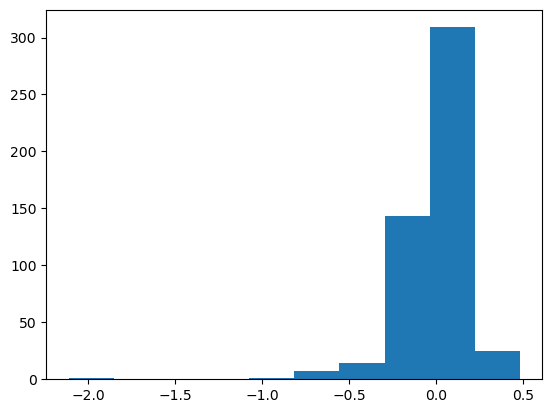

In [163]:
plt.hist(np.log(rpc_samples))

In [271]:
import matplotlib.pyplot as plt

In [577]:
np.quantile(crps_samples[:, 0]/crps_samples[:, 1], 0.14)

np.float32(1.0090802)

2.5

In [579]:
sum(crps_samples[:, 0]/crps_samples[:, 1] > 1)

np.int64(87)

In [39]:
bin_samples2

array([2.0173497e+03, 1.4500679e+00, 1.0000001e+00, 1.0785006e+03,
       8.4742322e+02, 1.0000001e+00, 1.0000001e+00, 1.0215071e+00,
       8.7935513e-01, 9.1836280e-01, 1.0000000e+00, 1.0048528e+00,
       8.7330568e-01, 2.8649755e+00, 1.0000000e+00, 1.0000001e+00,
       1.0000000e+00, 1.0000001e+00, 9.2919540e-01, 2.1270073e+03,
       1.0000000e+00, 1.0000001e+00, 1.0000001e+00, 1.0000000e+00,
       1.0000000e+00, 1.0000000e+00, 1.7831837e+03, 1.0000001e+00,
       1.0000001e+00, 9.9999994e-01, 1.2624491e+00, 1.6056241e+00,
       1.0000001e+00, 1.2353386e+00, 8.2136250e-01, 2.0914429e+03,
       9.9999994e-01, 1.0000002e+00, 4.5583856e+02, 1.0000000e+00,
       1.0000000e+00, 1.0000001e+00, 9.9999994e-01, 9.8252649e+02,
       1.0000000e+00, 9.1700548e-01, 1.0000001e+00, 1.4909694e+00,
       1.0000001e+00, 1.3281757e+03, 1.0000000e+00, 6.5292902e+02,
       1.1836810e+00, 1.0000002e+00, 8.5696979e+02, 1.0000000e+00,
       8.8449383e-01, 9.7973907e-01, 1.0941275e+00, 1.0000001e

In [583]:
np.save("Y.npy", Y)

In [584]:
np.save("ensemble.npy", ensemble)

In [603]:
(ensemble > 0).mean(axis=1), (Y.flatten() > 0).astype(int)

(array([0.36, 0.44, 0.72, 0.56, 0.24, 0.6 , 0.4 , 0.44, 0.2 , 0.64, 0.6 ,
        0.68, 0.6 , 0.36, 0.64, 0.2 , 0.04, 0.24, 0.32, 0.2 , 0.36, 0.36,
        0.44, 0.32, 0.48, 0.84, 0.32, 0.68, 0.48, 0.68, 0.72, 0.44, 0.68,
        0.08, 0.6 , 0.76, 0.32, 0.32, 0.56, 0.52, 0.56, 0.56, 0.44, 0.6 ,
        0.52, 0.44, 0.52, 0.48, 0.4 , 0.68, 0.12, 0.56, 0.56, 0.6 , 0.4 ,
        0.48, 0.72, 0.56, 0.48, 0.48, 0.68, 0.24, 0.44, 0.28, 0.32, 0.72,
        0.68, 0.56, 0.76, 0.6 , 0.52, 0.6 , 0.96, 0.64, 0.64, 0.56, 0.6 ,
        0.76, 0.6 , 0.48, 0.24, 0.6 , 0.44, 0.56, 0.32, 0.28, 0.76, 0.32,
        0.2 , 0.64, 0.48, 0.48, 0.84, 0.52, 0.32, 0.4 , 0.52, 0.52, 0.2 ,
        0.76]),
 array([1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
        1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
        0, 1, 0, 0, 1,

In [11]:
crps_samples

array([[0.77203184, 0.83484393],
       [0.7765574 , 0.7717365 ],
       [0.70939076, 0.67118615],
       [0.7594187 , 0.73441786],
       [0.75531197, 0.6860908 ],
       [0.7928153 , 0.8783419 ],
       [0.7446473 , 0.6846378 ],
       [0.7090964 , 0.6503363 ],
       [0.77965665, 0.7529159 ],
       [0.76924855, 0.72892916],
       [0.77454996, 0.7513767 ],
       [0.7767166 , 0.7596342 ],
       [0.7607041 , 0.73347056],
       [0.6827181 , 0.6867755 ],
       [0.7944946 , 0.7309276 ],
       [0.7927558 , 0.75484186],
       [0.79477113, 0.78122336],
       [0.7588844 , 0.7214503 ],
       [0.74233913, 0.6281158 ],
       [0.7248285 , 0.63136184],
       [0.7511808 , 0.7115736 ],
       [0.76078063, 0.74386495],
       [0.7818185 , 0.79428136],
       [0.7558935 , 0.67532605],
       [0.7747944 , 0.7910427 ],
       [0.76466316, 0.7533554 ],
       [0.7754374 , 0.8184026 ],
       [0.8269994 , 0.8869907 ],
       [0.7868717 , 0.83308965],
       [0.79337496, 0.8313633 ],
       [0.

In [32]:
np.quantile(crps_samples[:, 0]/crps_samples[:, 1], 0.5)

np.float32(1.0247928)

In [25]:
(rpc_samples > 1).sum()

np.int64(58)

(array([ 28.,  72., 124., 100.,  80.,  59.,  26.,   7.,   1.,   3.]),
 array([0.86839813, 0.91685259, 0.96530706, 1.01376152, 1.06221592,
        1.11067045, 1.15912485, 1.20757937, 1.25603378, 1.30448818,
        1.35294271]),
 <BarContainer object of 10 artists>)

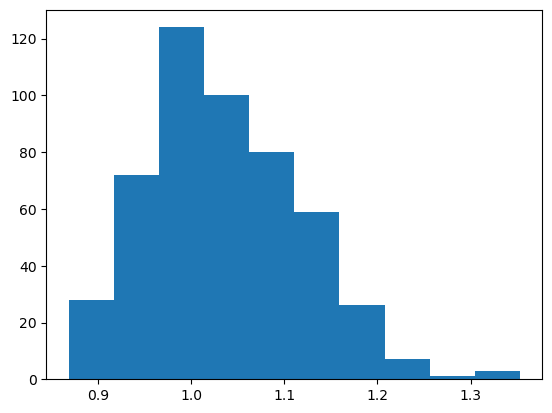

In [35]:
plt.hist(crps_samples[:, 0]/crps_samples[:, 1])

(array([  1.,   0.,   0.,   9.,  13.,  31., 183., 214.,  48.,   1.]),
 array([-0.29249328, -0.10600129,  0.08049071,  0.26698271,  0.45347471,
         0.63996671,  0.82645871,  1.01295071,  1.19944271,  1.3859347 ,
         1.5724267 ]),
 <BarContainer object of 10 artists>)

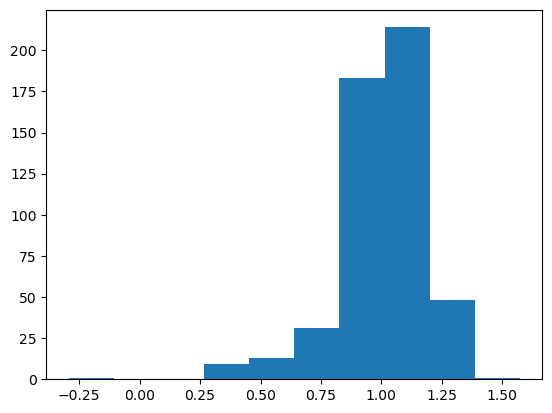

In [37]:
plt.hist(rpc_samples)

In [34]:
import matplotlib.pyplot as plt

In [46]:
score_SSCrat_bin(np.clip((ensemble > 0).mean(axis=1), 1e-6, 1 - 1e-6), (Y.flatten() > 0).astype(int), scoring_rule=scoringrules.brier_score)

[Array(-6.914139e-06, dtype=float32), Array(9.864569e-06, dtype=float32)] -0.20621914049920206 0.9675714200854855


Array(0.98882186, dtype=float32)

In [52]:
jax.scipy.special.expit(jax.scipy.special.logit(1-1e-6))

Array(0.9999989, dtype=float32, weak_type=True)

In [53]:
(ensemble > 0).mean(axis=1)

array([0.4 , 0.32, 0.2 , 0.08, 0.08, 0.6 , 0.24, 0.68, 0.72, 0.48, 0.48,
       0.24, 0.52, 0.4 , 0.2 , 0.64, 0.4 , 0.48, 0.76, 0.92, 0.6 , 0.24,
       0.88, 0.72, 0.36, 0.32, 1.  , 0.32, 0.16, 0.12, 0.56, 0.52, 0.68,
       0.32, 0.76, 0.6 , 0.28, 0.64, 0.6 , 0.32, 0.24, 1.  , 0.24, 0.16,
       0.84, 0.36, 0.88, 0.84, 0.28, 0.12, 0.4 , 0.44, 0.92, 0.68, 0.72,
       0.72, 0.16, 0.92, 0.64, 0.04, 0.72, 0.68, 0.56, 0.2 , 0.2 , 0.76,
       0.12, 0.36, 0.48, 0.2 , 0.28, 0.76, 0.96, 0.44, 0.28, 0.52, 0.28,
       0.36, 0.48, 0.76, 0.92, 0.28, 0.2 , 0.32, 0.24, 0.44, 0.68, 0.56,
       0.68, 0.84, 0.04, 0.04, 0.28, 0.6 , 0.64, 0.12, 0.32, 0.8 , 0.72,
       0.84])

In [45]:
np.clip((ensemble > 0).mean(axis=1), 1e-6, 1 - 1e-6)

array([0.4     , 0.32    , 0.2     , 0.08    , 0.08    , 0.6     ,
       0.24    , 0.68    , 0.72    , 0.48    , 0.48    , 0.24    ,
       0.52    , 0.4     , 0.2     , 0.64    , 0.4     , 0.48    ,
       0.76    , 0.92    , 0.6     , 0.24    , 0.88    , 0.72    ,
       0.36    , 0.32    , 0.999999, 0.32    , 0.16    , 0.12    ,
       0.56    , 0.52    , 0.68    , 0.32    , 0.76    , 0.6     ,
       0.28    , 0.64    , 0.6     , 0.32    , 0.24    , 0.999999,
       0.24    , 0.16    , 0.84    , 0.36    , 0.88    , 0.84    ,
       0.28    , 0.12    , 0.4     , 0.44    , 0.92    , 0.68    ,
       0.72    , 0.72    , 0.16    , 0.92    , 0.64    , 0.04    ,
       0.72    , 0.68    , 0.56    , 0.2     , 0.2     , 0.76    ,
       0.12    , 0.36    , 0.48    , 0.2     , 0.28    , 0.76    ,
       0.96    , 0.44    , 0.28    , 0.52    , 0.28    , 0.36    ,
       0.48    , 0.76    , 0.92    , 0.28    , 0.2     , 0.32    ,
       0.24    , 0.44    , 0.68    , 0.56    , 0.68    , 0.84 

In [154]:
score_SSCrat(ensemble, Y.flatten(), scoring_rule=scoringrules.crps_ensemble)

49.051216 48.762104 0.006684050035940938 1.1252273071891365
1.0474405


(np.float32(0.764536), np.float32(0.72990876))

In [155]:
0.764536/0.72990876

1.0474405047556903

Text(0.5, 0, '$\\log_{10}(\\text{SSC})$')

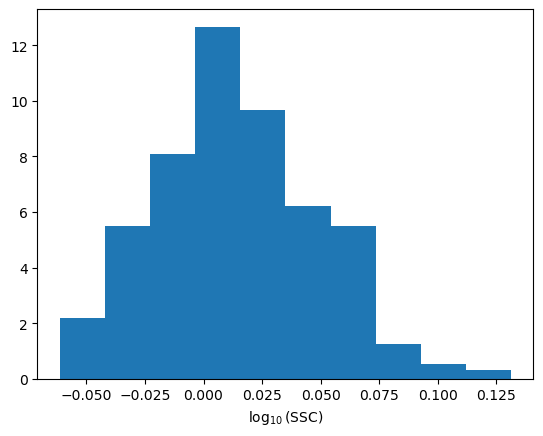

In [187]:
plt.hist(np.log10((crps_samples[:, 0]/crps_samples[:, 1])), density=True)
plt.xlabel(r"$\log_{10}(\text{SSC})$")

Text(0.5, 0, '$\\log_{10}(\\text{SSC})$')

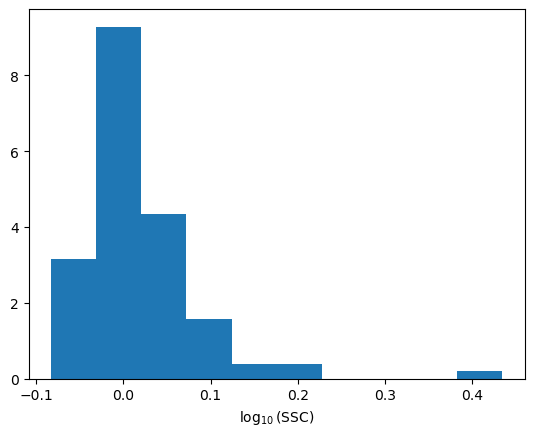

In [189]:
plt.hist(np.log10(bin_samples_log), density=True)
plt.xlabel(r"$\log_{10}(\text{SSC})$")

(array([16., 47., 22.,  8.,  2.,  2.,  0.,  0.,  0.,  1.]),
 array([-0.08264929, -0.0309903 ,  0.02066869,  0.07232767,  0.12398666,
         0.17564565,  0.22730464,  0.27896363,  0.33062261,  0.3822816 ,
         0.43394062]),
 <BarContainer object of 10 artists>)

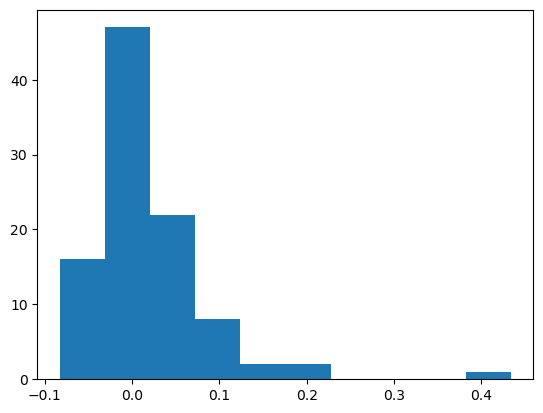

In [192]:
plt.hist(np.log10(bin_samples_log))

In [33]:
scipy.stats.kurtosis(np.log10(crps_samples[:, 0]/crps_samples[:, 1]))

np.float32(0.5069072)

In [201]:
np.var(np.log10(rpc_samples))

np.float64(0.007138984137121251)

In [202]:
np.mean(np.log10(crps_samples[:, 0]/crps_samples[:, 1]))

np.float32(0.014216185)

In [248]:
scipy.stats.kurtosis(np.log10(crps_samples[:, 0]/crps_samples[:, 1]))

np.float32(-0.13050127)

In [247]:
scipy.stats.kurtosis(np.log10(rpc_samples[:100]))

np.float64(1.927247138668326)

In [245]:
scipy.stats.kurtosis(np.log10(np.concatenate([bin_samples_log[~np.isnan(bin_samples_log)], bin_samples_log2])))

np.float32(12.764571)

In [246]:
scipy.stats.kurtosis(np.log10(crps_samples[:100, 0]/crps_samples[:100, 1]))

np.float32(-0.36618543)

In [434]:
rpc_samples.mean()

np.float64(1.0629048998045127)